# Statistical Testing

`experiment.ipynb`에서 저장한 `results/experiment_results.csv`를 로드해  
**Paired t-test (one-sided)**로 모델 간 성과 차이의 유의성을 검정한다.

실험 설계: **2×2 factorial** — {Graph, MLP} × {L1, L2}

|  | **L1 loss** | **L2 loss** |
|---|---|---|
| **Graph** | Graph-L1 | Graph-L2 |
| **MLP**   | MLP-L1   | MLP-L2   |

---

## 검정 구조 (2-Layer)

### Layer 1 — Proposed Models vs Baselines
모든 제안 전략이 baseline을 유의하게 상회하는지 검증.  
**Bonferroni 보정** 적용 (4개 비교 → α = 0.05/4 = **0.0125**)

| 쌍 | 비교 | 목적 |
|---|---|---|
| L1-1 | `Graph-L1` vs `EW`        | E2E GMV (variance loss) 유효성 검증 |
| L1-2 | `Graph-L1` vs `SampleGMV` | E2E vs 고전 GMV |
| L1-3 | `Graph-L2` vs `EW`        | E2E GMV (mean-var loss) 유효성 검증 |
| L1-4 | `Graph-L2` vs `SampleGMV` | Mean-Variance E2E vs 고전 GMV |

> MLP-L1 / MLP-L2는 ablation baseline이므로 Layer 1에서 제외.

### Layer 2 — RQ-Specific Comparisons
개별 설계 선택의 효과를 단독 비교로 격리.  
**보정 없음** (α = 0.05, 각 비교가 독립된 RQ에 대응)

| RQ | 쌍 | 비교 | 귀무가설 |
|---|---|---|---|
| **RQ2a** | `Graph-L1` vs `Graph-L2` | Graph 기준, loss 효과 | L1 ≥ L2 (Graph) |
| **RQ2b** | `MLP-L1`   vs `MLP-L2`   | MLP 기준, loss 효과 (일관성 검증) | L1 ≥ L2 (MLP) |
| **RQ3a** | `Graph-L1` vs `MLP-L1`   | L1 기준, graph 효과 | Graph ≥ MLP (L1) |
| **RQ3b** | `Graph-L2` vs `MLP-L2`   | L2 기준, graph 효과 (일관성 검증) | Graph ≥ MLP (L2) |

> RQ3 비교는 동일한 loss 하에서 architecture만 달리함 → graph 효과 순수 격리.  
> RQ2/RQ3 각각 2쌍이 모두 일관된 방향이면 결론이 더 강건해짐.

---

지표별 방향: `Ann. Return`↑  `Sharpe`↑  `Sortino`↑  `Max DD`↑ → `alternative='greater'`  
　　　　　　`Ann. Vol`↓  `CVaR`↓ → `alternative='less'`

In [6]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── 데이터 로드 ───────────────────────────────────────────────────────────
df = pd.read_csv('results/experiment_results.csv')

STRATEGY_ORDER = ['EW', 'SampleGMV', 'MLP-L1', 'MLP-L2', 'Graph-L1', 'Graph-L2']
COLORS = {
    'EW':         'gray',
    'SampleGMV':  'steelblue',
    'MLP-L1':     'mediumpurple',
    'MLP-L2':     'darkorchid',    # MLP 계열: purple 톤
    'Graph-L1':   'tomato',
    'Graph-L2':   'seagreen',
}
strategies = [s for s in STRATEGY_ORDER if s in df['strategy'].unique()]
METRICS    = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Sortino', 'Max DD', 'CVaR']
N_RUNS     = df['seed'].nunique()

def get_values(s: str, k: str) -> np.ndarray:
    """seed 오름차순으로 정렬된 metric 배열 반환"""
    return df[df['strategy'] == s].sort_values('seed')[k].values

print(f'Loaded : {len(df)} rows')
print(f'Seeds  : {N_RUNS}  ({df["seed"].min()} ~ {df["seed"].max()})')
print(f'Strategies: {strategies}')
df.head(len(strategies))

Loaded : 300 rows
Seeds  : 50  (0 ~ 49)
Strategies: ['EW', 'SampleGMV', 'MLP-L1', 'MLP-L2', 'Graph-L1', 'Graph-L2']


,seed,strategy,Ann. Return,Ann. Vol,Sharpe,Sortino,Max DD,CVaR
0,0,EW,0.142700,0.169868,0.840063,1.294659,-0.279261,0.114632
1,0,SampleGMV,0.094708,0.137060,0.690997,1.014862,-0.254371,0.096959
2,0,MLP-L1,0.081066,0.129314,0.626890,0.961646,-0.201712,0.085839
3,0,MLP-L2,0.153737,0.183711,0.836842,1.382621,-0.293509,0.114175
4,0,Graph-L1,0.207445,0.247595,0.837837,1.400750,-0.462006,0.141137
5,0,Graph-L2,0.199363,0.265414,0.751140,1.229943,-0.521943,0.143455


## 1. Descriptive Statistics

In [7]:
# ── Mean ± Std 요약 테이블 ────────────────────────────────────────────────
rows = []
for s in strategies:
    row = {'Strategy': s}
    for k in METRICS:
        v = get_values(s, k)
        row[k] = f'{v.mean():+.4f} ± {v.std():.4f}'
    rows.append(row)

desc = pd.DataFrame(rows).set_index('Strategy')
print(f'Mean ± Std  (N = {N_RUNS} seeds)')
print('=' * (14 + 20 * len(METRICS)))
print(desc.to_string())

Mean ± Std  (N = 50 seeds)
                Ann. Return          Ann. Vol            Sharpe           Sortino            Max DD              CVaR
Strategy                                                                                                             
EW         +0.1427 ± 0.0000  +0.1699 ± 0.0000  +0.8401 ± 0.0000  +1.2947 ± 0.0000  -0.2793 ± 0.0000  +0.1146 ± 0.0000
SampleGMV  +0.0947 ± 0.0000  +0.1371 ± 0.0000  +0.6910 ± 0.0000  +1.0149 ± 0.0000  -0.2544 ± 0.0000  +0.0970 ± 0.0000
MLP-L1     +0.0846 ± 0.0079  +0.1347 ± 0.0051  +0.6292 ± 0.0629  +0.9521 ± 0.1190  -0.2304 ± 0.0221  +0.0897 ± 0.0061
MLP-L2     +0.1628 ± 0.0290  +0.2044 ± 0.0138  +0.7968 ± 0.1355  +1.3016 ± 0.2787  -0.3367 ± 0.0479  +0.1263 ± 0.0107
Graph-L1   +0.2296 ± 0.0202  +0.2449 ± 0.0087  +0.9387 ± 0.0901  +1.6247 ± 0.1952  -0.4007 ± 0.0586  +0.1364 ± 0.0084
Graph-L2   +0.2005 ± 0.0283  +0.2396 ± 0.0087  +0.8377 ± 0.1220  +1.4157 ± 0.2488  -0.4556 ± 0.0862  +0.1365 ± 0.0093


## 2. Paired t-test

In [8]:
# ── Paired t-test: 2-Layer Structure ─────────────────────────────────────────
METRIC_DIRECTION = {
    'Ann. Return': 'greater',   # 높을수록 좋음
    'Ann. Vol':    'less',      # 낮을수록 좋음
    'Sharpe':      'greater',
    'Sortino':     'greater',
    'Max DD':      'greater',   # less negative = higher = better
    'CVaR':        'less',      # 낮을수록 좋음
}

# ── Layer 1: 제안 전략 vs 기준선  (Bonferroni α = 0.05/4 = 0.0125) ──────────
ALPHA_L1 = 0.05 / 4
PAIRS_L1 = [
    ('Graph-L1', 'EW',        'L1-1  Graph-L1 vs EW       '),
    ('Graph-L1', 'SampleGMV', 'L1-2  Graph-L1 vs SampleGMV'),
    ('Graph-L2', 'EW',        'L1-3  Graph-L2 vs EW       '),
    ('Graph-L2', 'SampleGMV', 'L1-4  Graph-L2 vs SampleGMV'),
]

# ── Layer 2: RQ별 단독 비교  (α = 0.05, 보정 없음) ────────────────────────
# RQ2: loss 효과  (Graph architecture 고정 / MLP architecture 고정)
# RQ3: graph 효과 (L1 loss 고정 / L2 loss 고정)
ALPHA_L2 = 0.05
PAIRS_L2 = [
    ('Graph-L1', 'Graph-L2', 'RQ2a  Graph: L1 vs L2       '),
    ('MLP-L1',   'MLP-L2',   'RQ2b  MLP:   L1 vs L2       '),
    ('Graph-L1', 'MLP-L1',   'RQ3a  L1:    Graph vs MLP   '),
    ('Graph-L2', 'MLP-L2',   'RQ3b  L2:    Graph vs MLP   '),
]


def sig_stars_l1(p: float) -> str:
    """Layer 1 — Bonferroni-corrected thresholds (α_bonf = 0.0125)"""
    if p < 0.001:   return '***'
    if p < 0.0125:  return '** '   # significant after Bonferroni
    if p < 0.05:    return '(*)' # marginal: sig without correction only
    return '   '


def sig_stars_l2(p: float) -> str:
    """Layer 2 — standard thresholds (α = 0.05)"""
    if p < 0.001: return '***'
    if p < 0.01:  return '** '
    if p < 0.05:  return '*  '
    return '   '


def run_layer(pairs, sig_fn, layer_header):
    W = 16
    rows = []
    print(f'\n{"═"*95}')
    print(layer_header)
    print(f'{"═"*95}')
    for s1, s2, label in pairs:
        print(f'\n{"─"*95}')
        print(label.strip())
        print(f'  {"":14}' + ''.join(f'{k:>{W}}' for k in METRICS))
        for s in [s1, s2]:
            cells = [f'{get_values(s,k).mean():>+7.4f}±{get_values(s,k).std():.4f}'
                     for k in METRICS]
            print(f'  {s:<14}' + ''.join(f'  {c}' for c in cells))
        print(f'  {"":14}  ' + '─' * (W * len(METRICS)))
        t_vals, p_vals = [], []
        for k in METRICS:
            x1, x2 = get_values(s1, k), get_values(s2, k)
            t, p    = stats.ttest_rel(x1, x2, alternative=METRIC_DIRECTION[k])
            t_vals.append(t); p_vals.append(p)
            rows.append({
                'Layer':     layer_header.split('—')[0].strip(),
                'Pair':      label.strip(),
                'Model A':   s1, 'Model B': s2,
                'Metric':    k,
                'Direction': METRIC_DIRECTION[k],
                't-stat':    round(t, 4),
                'p-value':   round(p, 4),
                'sig':       sig_fn(p).strip(),
            })
        print(f'  {"t-stat":<14}' + ''.join(f'  {t:>+12.3f}  ' for t in t_vals))
        print(f'  {"p-value":<14}' + ''.join(f'  {p:>8.3f} {sig_fn(p)} ' for p in p_vals))
    return rows


print(f'Paired t-test  (one-sided,  N = {N_RUNS} seeds)')
print(f'Significance (Layer 1, Bonferroni): *** p<0.001   ** p<0.0125   (*) p<0.05')
print(f'Significance (Layer 2, standard) : *** p<0.001   ** p<0.01     *   p<0.05')

all_rows  = run_layer(PAIRS_L1, sig_stars_l1,
                      'Layer 1 — Proposed Models vs Baselines  [Bonferroni α = 0.0125]')
all_rows += run_layer(PAIRS_L2, sig_stars_l2,
                      'Layer 2 — RQ-Specific Comparisons  [α = 0.05, no correction]')

print(f'\n{"═"*95}')
print('t > 0 → A 쪽이 더 높음   t < 0 → B 쪽이 더 높음')

df_ttest = pd.DataFrame(all_rows)
df_ttest.to_csv('results/ttest_results.csv', index=False)
print('\nSaved → results/ttest_results.csv')

Paired t-test  (one-sided,  N = 50 seeds)
Significance (Layer 1, Bonferroni): *** p<0.001   ** p<0.0125   (*) p<0.05
Significance (Layer 2, standard) : *** p<0.001   ** p<0.01     *   p<0.05

═══════════════════════════════════════════════════════════════════════════════════════════════
Layer 1 — Proposed Models vs Baselines  [Bonferroni α = 0.0125]
═══════════════════════════════════════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────────────────────────────────────────────
L1-1  Graph-L1 vs EW
                     Ann. Return        Ann. Vol          Sharpe         Sortino          Max DD            CVaR
  Graph-L1        +0.2296±0.0202  +0.2449±0.0087  +0.9387±0.0901  +1.6247±0.1952  -0.4007±0.0586  +0.1364±0.0084
  EW              +0.1427±0.0000  +0.1699±0.0000  +0.8401±0.0000  +1.2947±0.0000  -0.2793±0.0000  +0.1146±0.0000
                  ─────────────────────────────────────────────────────────────────────────────

## 3. Distribution Visualization

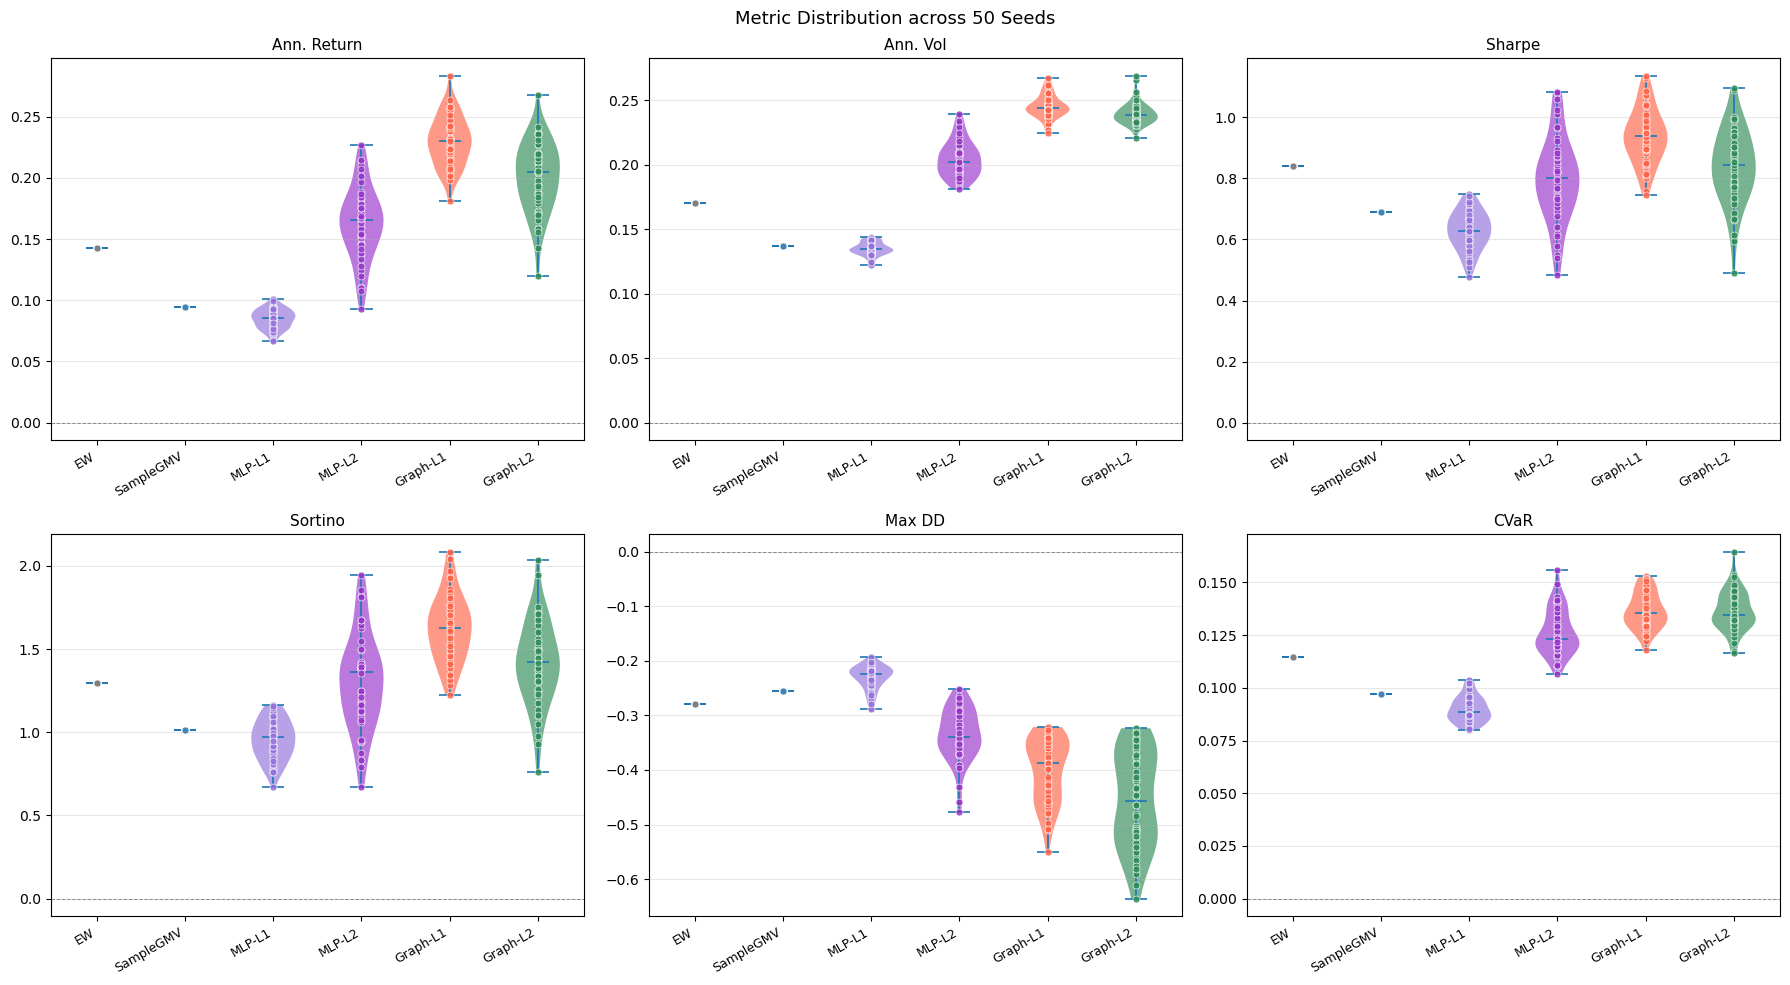

In [14]:
# ── Violin plot: metric별 분포 ────────────────────────────────────────────
n_cols = len(METRICS) // 2          # 3  ← // 정수 나눗셈
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * len(METRICS), 10))

for ax, k in zip(axes.flatten(), METRICS):   # flatten() → 6개 ax 순서대로
    data  = [get_values(s, k) for s in strategies]
    parts = ax.violinplot(data, positions=range(len(strategies)),
                          showmedians=True, showextrema=True)
    for pc, s in zip(parts['bodies'], strategies):
        pc.set_facecolor(COLORS.get(s, 'blue'))
        pc.set_alpha(0.65)
    for part_name in ('cmedians', 'cmins', 'cmaxes', 'cbars'):
        parts[part_name].set_linewidth(1.2)

    for i, s in enumerate(strategies):
        v = get_values(s, k)
        ax.scatter([i] * len(v), v, color=COLORS.get(s, 'blue'),
                   s=25, zorder=3, alpha=0.85, edgecolors='white', linewidths=0.5)

    ax.set_xticks(range(len(strategies)))
    ax.set_xticklabels(strategies, rotation=30, ha='right', fontsize=9)
    ax.set_title(k, fontsize=11)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle(f'Metric Distribution across {N_RUNS} Seeds', fontsize=13)
plt.tight_layout()
plt.savefig('results/stat_distributions.png', dpi=450, bbox_inches='tight')
plt.show()

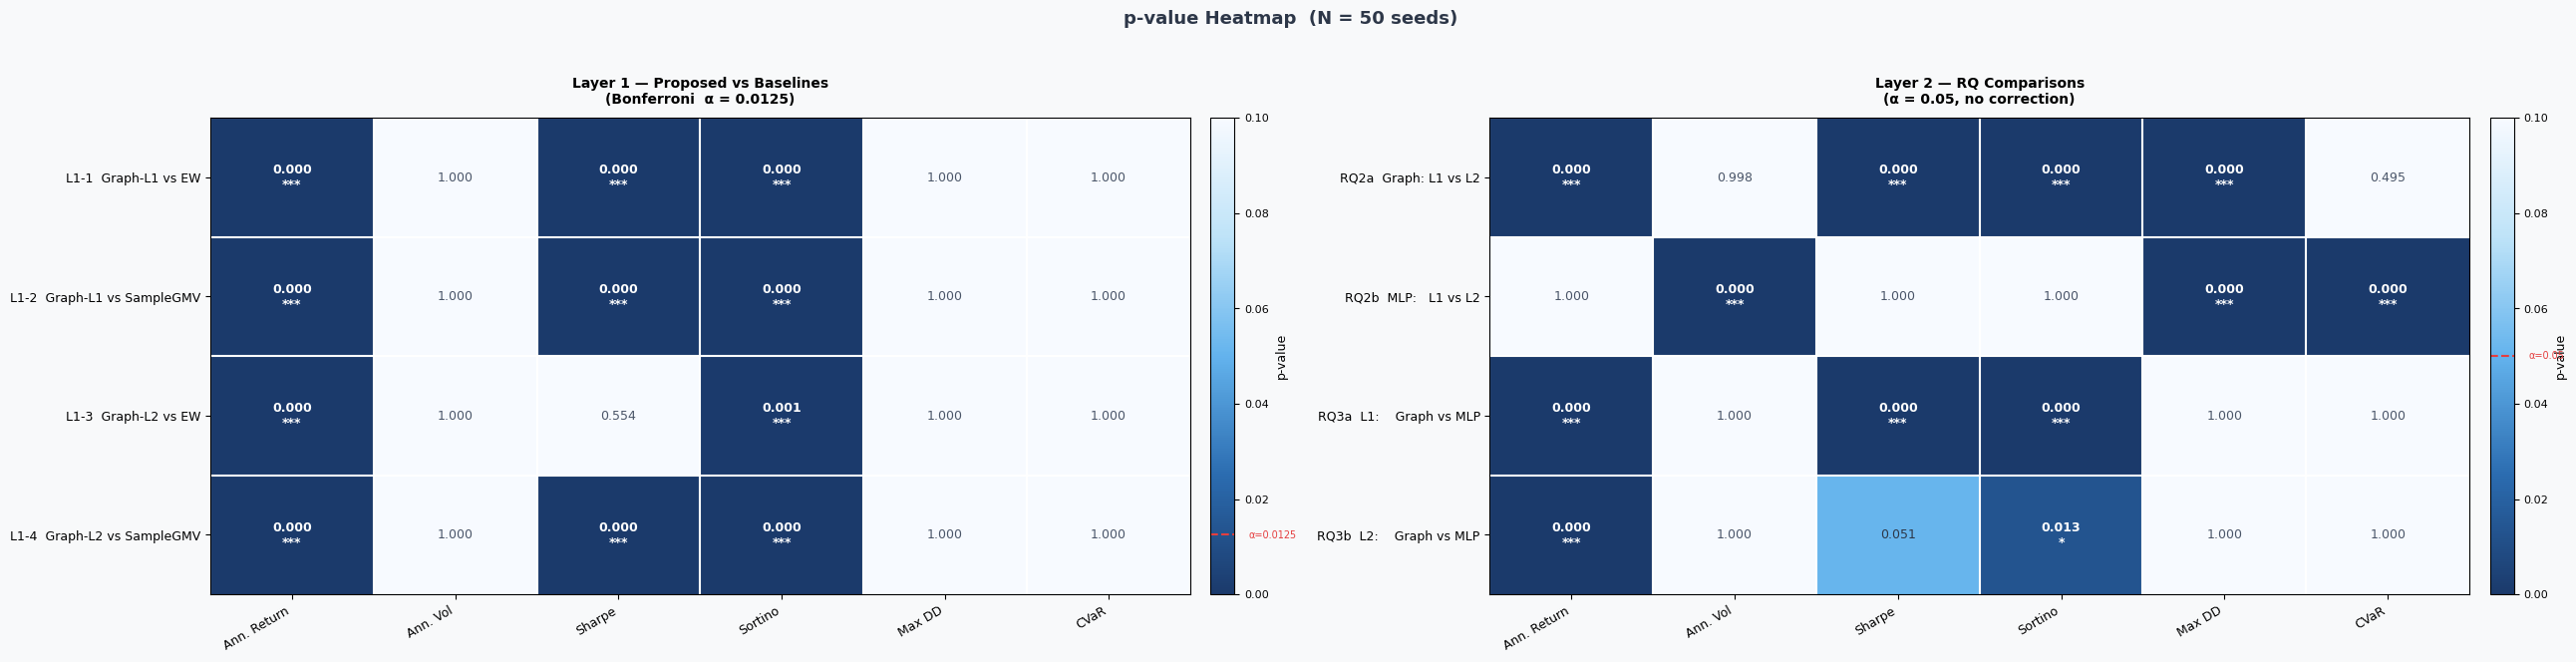

In [16]:
# ── p-value heatmap: Layer별 분리 표시 ──────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

# p=0 (significant) → 진한 인디고/네이비  /  p=0.1 (not sig) → 아이보리/흰색
_cmap = LinearSegmentedColormap.from_list(
    'sig',
    ['#1b3a6b',   # p≈0      deep navy
     '#2b6cb0',   # p≈0.025  cobalt
     '#63b3ed',   # p≈0.05   sky blue
     '#bee3f8',   # p≈0.075  pale blue
     '#f7faff'],  # p≈0.1    near white
    N=256,
)

n_rows_plot = max(len(PAIRS_L1), len(PAIRS_L2))
fig, axes = plt.subplots(
    1, 2,
    figsize=(len(METRICS) * 2.0 * 2 + 2, n_rows_plot * 1.1 + 2.0),
)
fig.patch.set_facecolor('#f8f9fa')   # 연한 회색 배경

for ax, layer_tag, pairs, title in [
    (axes[0], 'Layer 1', PAIRS_L1,
     'Layer 1 — Proposed vs Baselines\n(Bonferroni  α = 0.0125)'),
    (axes[1], 'Layer 2', PAIRS_L2,
     'Layer 2 — RQ Comparisons\n(α = 0.05, no correction)'),
]:
    sub        = df_ttest[df_ttest['Layer'].str.startswith(layer_tag)]
    row_labels = [p[2].strip() for p in pairs]
    data       = np.zeros((len(row_labels), len(METRICS)))

    for i, (s1, s2, lbl) in enumerate(pairs):
        lbl_s = lbl.strip()
        for j, k in enumerate(METRICS):
            val = sub[(sub['Pair'] == lbl_s) & (sub['Metric'] == k)]['p-value']
            data[i, j] = float(val.values[0]) if len(val) else np.nan

    im = ax.imshow(data, vmin=0, vmax=0.1, cmap=_cmap, aspect='auto')

    # ── 셀 텍스트 ────────────────────────────────────────────────────────
    for i in range(len(row_labels)):
        for j in range(len(METRICS)):
            pval = data[i, j]
            if np.isnan(pval):
                continue
            stars = (sig_stars_l1 if layer_tag == 'Layer 1' else sig_stars_l2)(pval).strip()
            txt   = f'{pval:.3f}\n{stars}' if stars else f'{pval:.3f}'
            # 셀이 어두울수록 흰 글씨
            fc = 'white' if pval < 0.04 else ('#2d3748' if pval < 0.08 else '#4a5568')
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=9, fontweight='bold' if stars else 'normal', color=fc)

    # ── 눈금선(grid) ─────────────────────────────────────────────────────
    ax.set_xticks(np.arange(len(METRICS)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(row_labels)) - 0.5, minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    ax.set_xticks(range(len(METRICS)))
    ax.set_xticklabels(METRICS, fontsize=9, rotation=30, ha='right')
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(title, fontsize=10, pad=10, fontweight='bold')
    ax.set_facecolor('#f8f9fa')

    cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label('p-value', fontsize=9)
    cb.ax.tick_params(labelsize=8)

    # α 임계선 표시
    alpha_thr = 0.0125 if layer_tag == 'Layer 1' else 0.05
    cb.ax.axhline(alpha_thr, color='#e53e3e', linewidth=1.5, linestyle='--')
    cb.ax.text(1.6, alpha_thr, f'α={alpha_thr}', va='center',
               fontsize=7, color='#e53e3e', transform=cb.ax.transData)

plt.suptitle(
    f'p-value Heatmap  (N = {N_RUNS} seeds)',
    fontsize=13, fontweight='bold', y=1.03, color='#2d3748'
)
plt.tight_layout()
plt.savefig('results/pvalue_heatmap.png', dpi=450, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()